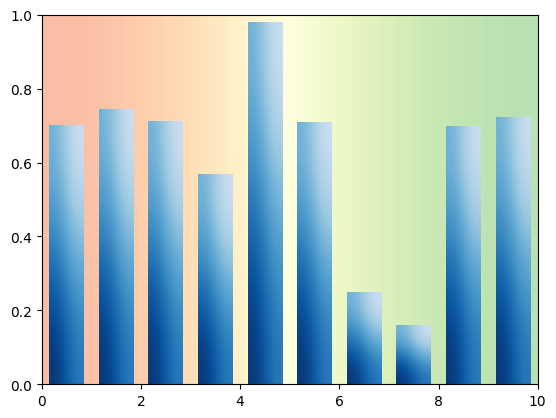

In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(19680801)


def gradient_image(ax, direction=0.3, cmap_range=(0, 1), **kwargs):
    """
    Draw a gradient image based on a colormap.

    Parameters:
    ------------
    :param ax: Axes
               The Axes to draw on.
    :param direction: float
                      The direction of the gradient. This is a number in
                      range 0 (=vertical) to 1 (=horizontal).
    :param cmap_range: float, float
                       The fraction (cmin, cmax) of the colormap that should be
                       used for the gradient, where the complete colormap is (0, 1).
    :param kwargs:
                    Other parameters are passed on to `.Axes.imshow()`.
                    In particular, *cmap*, *extent*, and *transform* may be useful.
    """
    phi = direction * np.pi / 2
    v = np.array([np.cos(phi), np.sin(phi)])
    X = np.array(
        [
            [v @ [1, 0], v @ [1, 1]],
            [v @ [0, 0], v @ [0, 1]],
        ]
    )
    a, b = cmap_range
    X = a + (b - a) / X.max() * X
    im = ax.imshow(
        X,
        interpolation="bicubic",
        clim=(0, 1),
        aspect="auto",
        **kwargs,
    )

    return im


def gradient_bar(ax, x, y, width=0.5, bottom=0):
    for left, top in zip(x, y):
        right = left + width
        gradient_image(
            ax,
            extent=(left, right, bottom, top),
            cmap=plt.cm.Blues_r,
            cmap_range=(0, 0.8),
        )


fig, ax = plt.subplots()
ax.set(xlim=(0, 10), ylim=(0, 1))

# background image
gradient_image(
    ax,
    direction=1,
    extent=(0, 1, 0, 1),
    transform=ax.transAxes,
    cmap=plt.cm.RdYlGn,
    cmap_range=(0.2, 0.8),
    alpha=0.5,
)

N = 10
x = np.arange(N) + 0.15
y = np.random.rand(N)
gradient_bar(ax, x, y, width=0.7)

plt.show()